# Zero-Shot vs Few-Shot VC Scoring Comparison
Compare LLM-predicted VC scores against human ground-truth scores from the BeauVis study.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load data
gt = pd.read_csv(r'pair_images_in_random.csv')
zs = pd.read_csv(r'D:/Coding/Image_VC_zeroshots/vc_scores.csv')
fs = pd.read_csv(r'D:/Coding/Image_VC_fewshots/vc_scores.csv')

# Merge on image name
df = gt.rename(columns={'NormalizedVC': 'gt_vc'})
df = df.merge(zs[['filename', 'vc_score']].rename(columns={'filename': 'imageName', 'vc_score': 'zs_vc'}), on='imageName')
df = df.merge(fs[['filename', 'vc_score']].rename(columns={'filename': 'imageName', 'vc_score': 'fs_vc'}), on='imageName')

df['zs_error'] = df['zs_vc'] - df['gt_vc']
df['fs_error'] = df['fs_vc'] - df['gt_vc']

print(f'Matched images: {len(df)}')
df.sort_values('gt_vc')

Matched images: 20


,imageName,gt_vc,zs_vc,fs_vc,zs_error,fs_error
0,wsj135.png,0.35,0.30,0.32,-0.05,-0.03
1,SciVisJ.1025.11.png,0.36,0.34,0.31,-0.02,-0.05
2,visMost97.png,0.38,0.22,0.22,-0.16,-0.16
3,economist_daily_chart_165.png,0.43,0.31,0.33,-0.12,-0.10
4,whoO06_2.png,0.45,0.38,0.36,-0.07,-0.09
5,InfoVisC.133.5(3).png,0.48,0.41,0.42,-0.07,-0.06
6,whoQ44_4.png,0.52,0.38,0.40,-0.14,-0.12
7,InfoVisJ.619.17.png,0.54,0.53,0.52,-0.01,-0.02
8,InfoVisJ.1558.11(3).png,0.57,0.33,0.30,-0.24,-0.27
9,wsj603.png,0.57,0.41,0.41,-0.16,-0.16


## Summary Statistics

In [3]:
def compute_metrics(y_true, y_pred, label):
    r, p = stats.pearsonr(y_true, y_pred)
    rho, p_rho = stats.spearmanr(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    return {
        'Method': label,
        'Pearson r': f'{r:.3f}',
        'R²': f'{r**2:.3f}',
        'Spearman ρ': f'{rho:.3f}',
        'MAE': f'{mae:.3f}',
        'RMSE': f'{rmse:.3f}',
        'Mean Bias': f'{bias:+.3f}',
    }

metrics = pd.DataFrame([
    compute_metrics(df['gt_vc'], df['zs_vc'], 'Zero-Shot'),
    compute_metrics(df['gt_vc'], df['fs_vc'], 'Few-Shot'),
]).set_index('Method')
metrics

,Pearson r,R²,Spearman ρ,MAE,RMSE,Mean Bias
Method,,,,,,
Zero-Shot,0.866,0.750,0.833,0.125,0.146,-0.125
Few-Shot,0.906,0.821,0.879,0.102,0.121,-0.099


## Regression Plots

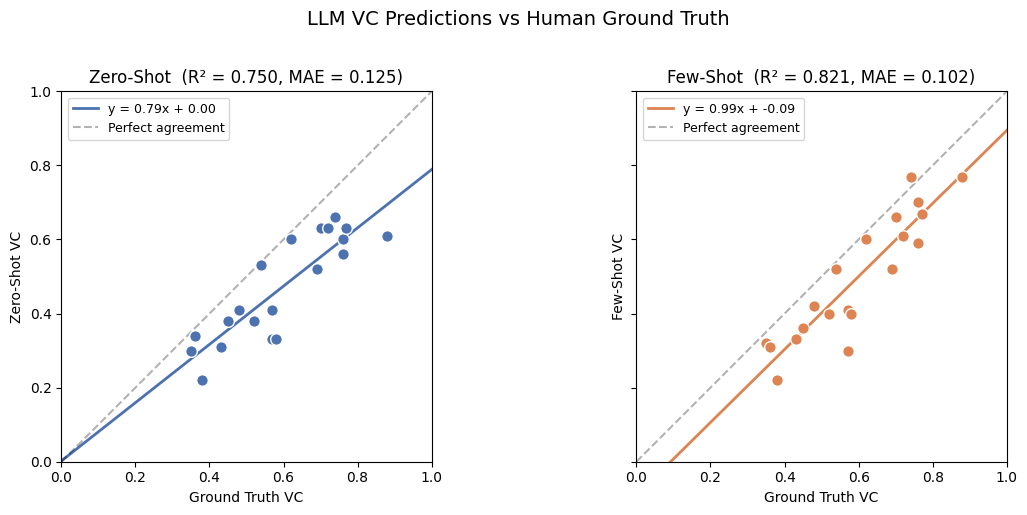

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, col, label, color in [
    (axes[0], 'zs_vc', 'Zero-Shot', '#4C72B0'),
    (axes[1], 'fs_vc', 'Few-Shot',  '#DD8452'),
]:
    x, y = df['gt_vc'], df[col]
    slope, intercept, r, p, se = stats.linregress(x, y)
    x_fit = np.linspace(0, 1, 100)
    y_fit = slope * x_fit + intercept

    ax.scatter(x, y, c=color, edgecolors='white', s=70, zorder=3)
    ax.plot(x_fit, y_fit, c=color, linewidth=2, label=f'y = {slope:.2f}x + {intercept:.2f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect agreement')
    ax.set_xlabel('Ground Truth VC')
    ax.set_ylabel(f'{label} VC')
    ax.set_title(f'{label}  (R² = {r**2:.3f}, MAE = {mean_absolute_error(x, y):.3f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle('LLM VC Predictions vs Human Ground Truth', fontsize=14, y=1.02)
fig.tight_layout()
import os
os.makedirs('results', exist_ok=True)

fig.savefig('results/zs_vs_fs_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Distribution

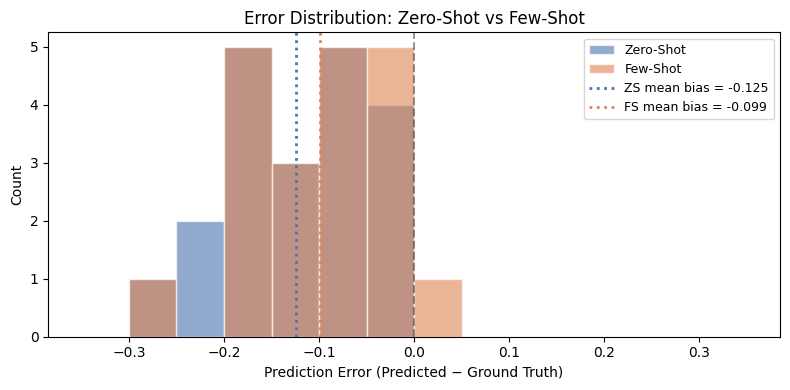

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = np.arange(-0.35, 0.40, 0.05)
ax.hist(df['zs_error'], bins=bins, alpha=0.6, color='#4C72B0', edgecolor='white', label='Zero-Shot')
ax.hist(df['fs_error'], bins=bins, alpha=0.6, color='#DD8452', edgecolor='white', label='Few-Shot')
ax.axvline(0, color='black', linestyle='--', alpha=0.4)
ax.axvline(df['zs_error'].mean(), color='#4C72B0', linestyle=':', linewidth=2,
           label=f'ZS mean bias = {df["zs_error"].mean():+.3f}')
ax.axvline(df['fs_error'].mean(), color='#DD8452', linestyle=':', linewidth=2,
           label=f'FS mean bias = {df["fs_error"].mean():+.3f}')

ax.set_xlabel('Prediction Error (Predicted − Ground Truth)')
ax.set_ylabel('Count')
ax.set_title('Error Distribution: Zero-Shot vs Few-Shot')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig('results/zs_vs_fs_error_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-Image Comparison

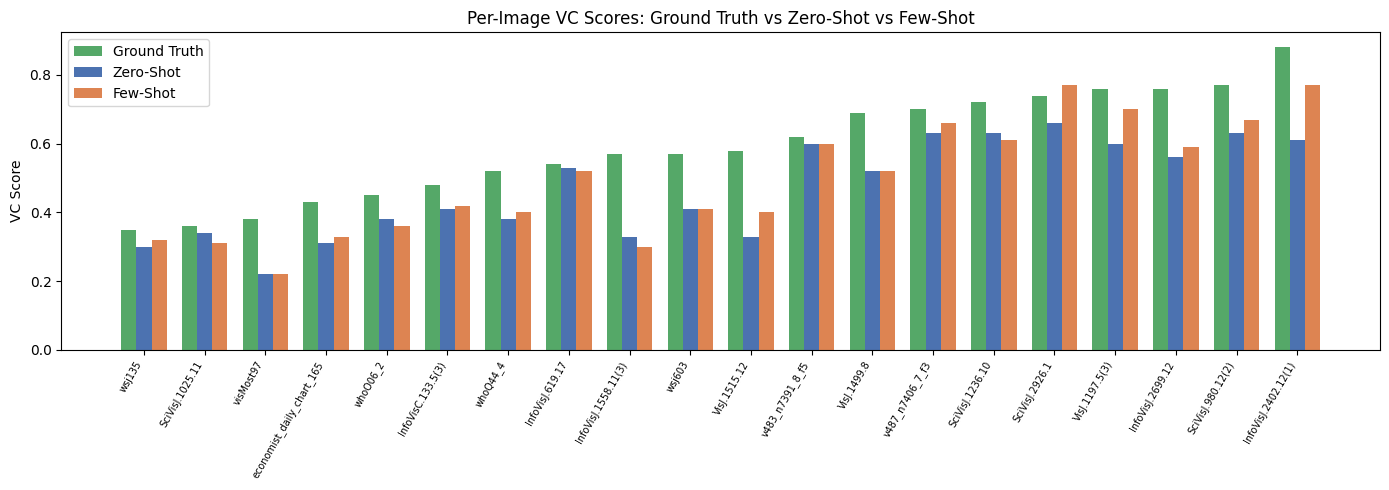

In [7]:
plot_df = df.sort_values('gt_vc').reset_index(drop=True)
x_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - 0.25, plot_df['gt_vc'],  width=0.25, color='#55A868', label='Ground Truth')
ax.bar(x_pos,        plot_df['zs_vc'],   width=0.25, color='#4C72B0', label='Zero-Shot')
ax.bar(x_pos + 0.25, plot_df['fs_vc'],   width=0.25, color='#DD8452', label='Few-Shot')

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_df['imageName'].str.replace('.png', '', regex=False),
                    rotation=60, ha='right', fontsize=7)
ax.set_ylabel('VC Score')
ax.set_title('Per-Image VC Scores: Ground Truth vs Zero-Shot vs Few-Shot')
ax.legend()
fig.tight_layout()
fig.savefig('results/zs_vs_fs_per_image.png', dpi=150, bbox_inches='tight')
plt.show()

## Dimension-Level Comparison
Which scoring dimensions differ most between zero-shot and few-shot?

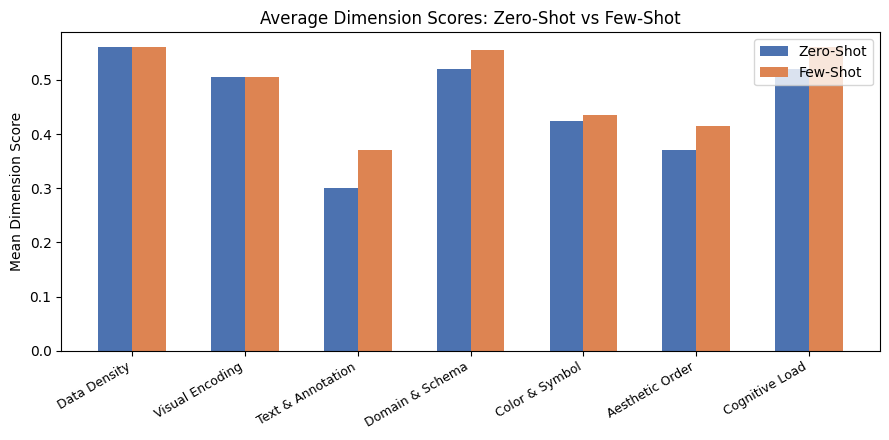

In [8]:
dims = ['data_density', 'visual_encoding', 'text_annotation',
        'domain_schema', 'color_symbol', 'aesthetic_order', 'cognitive_load']
dim_labels = ['Data Density', 'Visual Encoding', 'Text & Annotation',
              'Domain & Schema', 'Color & Symbol', 'Aesthetic Order', 'Cognitive Load']

zs_means = zs[dims].mean()
fs_means = fs[dims].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
x_pos = np.arange(len(dims))
ax.bar(x_pos - 0.15, zs_means, width=0.3, color='#4C72B0', label='Zero-Shot')
ax.bar(x_pos + 0.15, fs_means, width=0.3, color='#DD8452', label='Few-Shot')
ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Mean Dimension Score')
ax.set_title('Average Dimension Scores: Zero-Shot vs Few-Shot')
ax.legend()
fig.tight_layout()
fig.savefig('results/zs_vs_fs_dimensions.png', dpi=150, bbox_inches='tight')
plt.show()